In [1]:
import matplotlib.pyplot as plt
import h5py

import numpy as np
from matplotlib import ticker, font_manager
import warnings
warnings.filterwarnings("ignore")
def ticks_figure(ax):
    ax.xaxis.set_tick_params(width=1,length=8)
    ax.yaxis.set_tick_params(width=1,length=8)
    ax.xaxis.set_tick_params(which='minor',width=1,length=4)
    ax.yaxis.set_tick_params(which='minor',width=1,length=4)
    ax.xaxis.set_tick_params(tickdir="in", left="True",labelleft="True",right="True")
    ax.yaxis.set_tick_params(tickdir="in", left="True",labelleft="True",right="True")
    ax.xaxis.set_tick_params(tickdir="in", left="True",which='minor',labelleft="True",right="True")
    ax.yaxis.set_tick_params(tickdir="in", left="True",which='minor',labelleft="True",right="True")
    ax.minorticks_on()
    return

In [2]:
def my_interp2d(f, rad, radnew):
    import numpy as np
    import scipy.interpolate as inp
    r = rad
    rnew = radnew
    fnew = np.zeros_like(f)
    for i in range(f.shape[0]):
        val = f[i, :]
        tckp = inp.splrep(r, val)
        fnew[i, :] = inp.splev(rnew, tckp)

    return fnew
    
def plot_stream(r,theta,vr_n,vtheta_n,density,label=None,clim=[0,0]):

    rad = np.linspace(r[-1], r[0], len(r))
    theta = np.linspace(0,np.pi,len(theta))

    rr, ttheta = np.meshgrid(rad, theta)
    plt.figure()
    fig,ax = plt.subplots(1,1,figsize=(6,6),subplot_kw={'projection': 'polar'})

    un = vr_n[:,::-1]
    vn = vtheta_n[:,::-1]/rr[:,::-1]

    un = my_interp2d(un, r[::-1], rad)
    vn = my_interp2d(vn, r[::-1], rad)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rorigin(0)
    ax.set_ylim(r.min(),r.max())
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    strm = ax.streamplot(ttheta.T,rr.T,vn.T,un.T,color='#d95f02',density=density,
                         broken_streamlines=True,linewidth=1)

    fig.tight_layout()
    

Text(0.5, 1.0, '$t =$10.2')

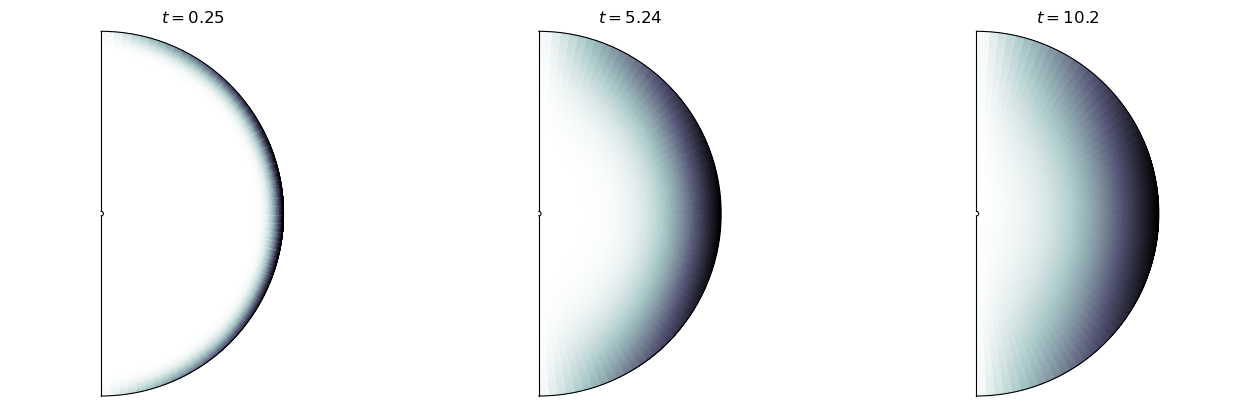

In [3]:
Delta_Omega=0.001

fig,ax = plt.subplots(1,3,figsize=(16,8),subplot_kw={'projection': 'polar'})

dire = './AZ_avg/AZ_avg_s1.h5'
data = h5py.File(dire, mode='r')
u_n_phi = data['tasks']['u_n_phi']    
time = np.array(data['scales/sim_time'])  
theta = u_n_phi.dims[2][0][:].ravel()
r = u_n_phi.dims[3][0][:].ravel()

j = 10

u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[0].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[0].set_theta_zero_location('N')
ax[0].set_theta_direction(-1)
ax[0].set_rorigin(0)
ax[0].set_ylim(r.min(),r.max())
ax[0].set_thetamin(0)
ax[0].set_thetamax(180)
ax[0].grid(False)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title(r'$t =$'+str(time[j])[:4])


dire = './AZ_avg/AZ_avg_s3.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[1].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[1].set_theta_zero_location('N')
ax[1].set_theta_direction(-1)
ax[1].set_rorigin(0)
ax[1].set_ylim(r.min(),r.max())
ax[1].set_thetamin(0)
ax[1].set_thetamax(180)
ax[1].grid(False)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title(r'$t =$'+str(time[j])[:4])

dire = './AZ_avg/AZ_avg_s5.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[2].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[2].set_theta_zero_location('N')
ax[2].set_theta_direction(-1)
ax[2].set_rorigin(0)
ax[2].set_ylim(r.min(),r.max())
ax[2].set_thetamin(0)
ax[2].set_thetamax(180)
ax[2].grid(False)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title(r'$t =$'+str(time[j])[:4])


Text(0.5, 1.0, '$t =$25.2')

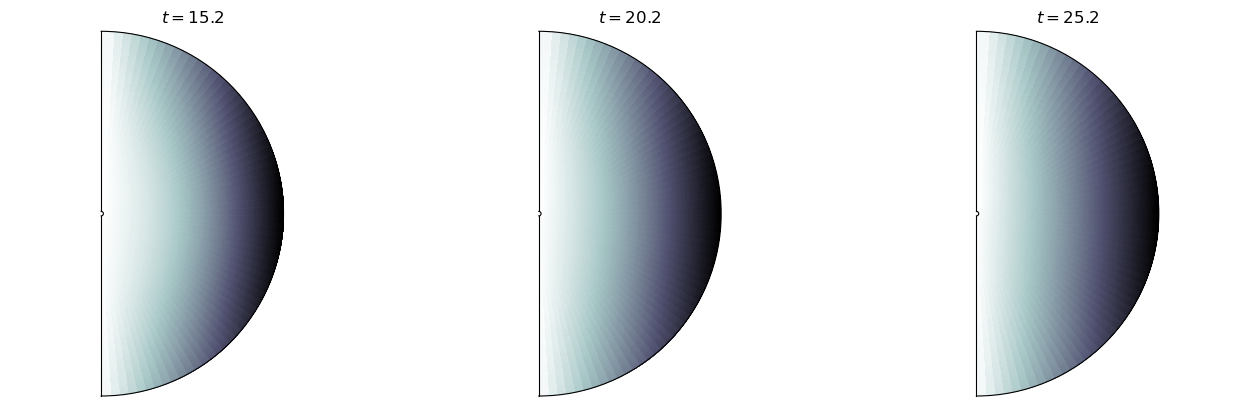

In [4]:
Delta_Omega=0.001

fig,ax = plt.subplots(1,3,figsize=(16,8),subplot_kw={'projection': 'polar'})

dire = './AZ_avg/AZ_avg_s7.h5'
data = h5py.File(dire, mode='r')
u_n_phi = data['tasks']['u_n_phi']    
time = np.array(data['scales/sim_time'])  
theta = u_n_phi.dims[2][0][:].ravel()
r = u_n_phi.dims[3][0][:].ravel()

j = 10

u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[0].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[0].set_theta_zero_location('N')
ax[0].set_theta_direction(-1)
ax[0].set_rorigin(0)
ax[0].set_ylim(r.min(),r.max())
ax[0].set_thetamin(0)
ax[0].set_thetamax(180)
ax[0].grid(False)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title(r'$t =$'+str(time[j])[:4])


dire = './AZ_avg/AZ_avg_s9.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[1].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[1].set_theta_zero_location('N')
ax[1].set_theta_direction(-1)
ax[1].set_rorigin(0)
ax[1].set_ylim(r.min(),r.max())
ax[1].set_thetamin(0)
ax[1].set_thetamax(180)
ax[1].grid(False)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title(r'$t =$'+str(time[j])[:4])

dire = './AZ_avg/AZ_avg_s11.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[2].pcolormesh(theta_m,r_m,u_n_phi,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[2].set_theta_zero_location('N')
ax[2].set_theta_direction(-1)
ax[2].set_rorigin(0)
ax[2].set_ylim(r.min(),r.max())
ax[2].set_thetamin(0)
ax[2].set_thetamax(180)
ax[2].grid(False)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title(r'$t =$'+str(time[j])[:4])

Text(0.5, 1.0, '$t =$10.2')

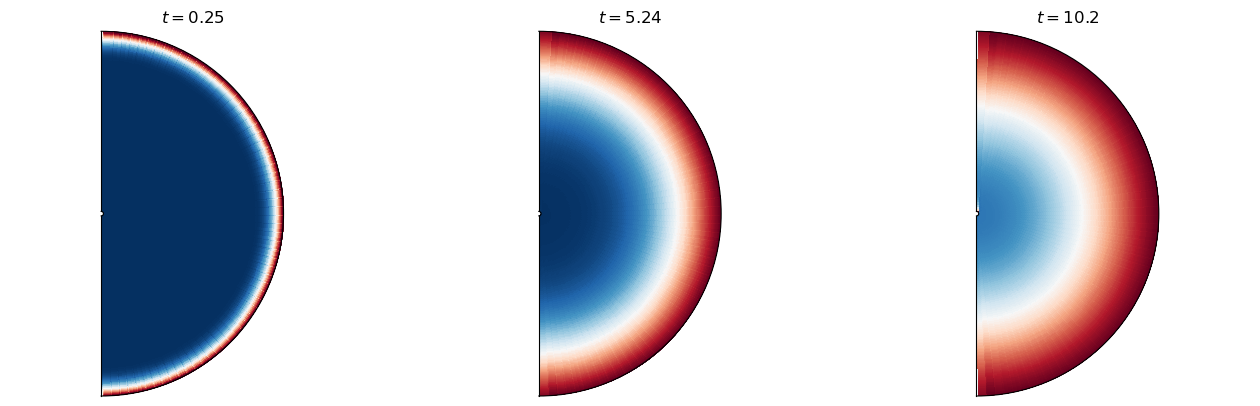

In [5]:
Delta_Omega=0.001

fig,ax = plt.subplots(1,3,figsize=(16,8),subplot_kw={'projection': 'polar'})

dire = './AZ_avg/AZ_avg_s1.h5'
data = h5py.File(dire, mode='r')
u_n_phi = data['tasks']['u_n_phi']    
time = np.array(data['scales/sim_time'])  
theta = u_n_phi.dims[2][0][:].ravel()
r = u_n_phi.dims[3][0][:].ravel()

j = 10

u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[0].pcolormesh(theta_m,r_m,omega,clim=(0,Delta_Omega),cmap='RdBu_r',edgecolors='face')
ax[0].set_theta_zero_location('N')
ax[0].set_theta_direction(-1)
ax[0].set_rorigin(0)
ax[0].set_ylim(r.min(),r.max())
ax[0].set_thetamin(0)
ax[0].set_thetamax(180)
ax[0].grid(False)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title(r'$t =$'+str(time[j])[:4])


dire = './AZ_avg/AZ_avg_s3.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[1].pcolormesh(theta_m,r_m,omega,clim=(0,Delta_Omega),cmap='RdBu_r',edgecolors='face')
ax[1].set_theta_zero_location('N')
ax[1].set_theta_direction(-1)
ax[1].set_rorigin(0)
ax[1].set_ylim(r.min(),r.max())
ax[1].set_thetamin(0)
ax[1].set_thetamax(180)
ax[1].grid(False)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title(r'$t =$'+str(time[j])[:4])

dire = './AZ_avg/AZ_avg_s5.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[2].pcolormesh(theta_m,r_m,omega,clim=(0,Delta_Omega),cmap='RdBu_r',edgecolors='face')
ax[2].set_theta_zero_location('N')
ax[2].set_theta_direction(-1)
ax[2].set_rorigin(0)
ax[2].set_ylim(r.min(),r.max())
ax[2].set_thetamin(0)
ax[2].set_thetamax(180)
ax[2].grid(False)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title(r'$t =$'+str(time[j])[:4])

In [6]:
dire = './AZ_avg/AZ_avg_s60.h5'
data = h5py.File(dire, mode='r')
time = np.array(data['scales/sim_time']) 
u_n_phi = data['tasks']['u_n_phi'][j,-1,:,:]

#Convert v_phi to an Angular velocity
omega=np.zeros((len(theta),len(r)))
for i in range(len(r)):
    omega[:,i]=u_n_phi[:,i]/(r[i]*np.sin(theta)[:])
r_m, theta_m = np.meshgrid(r,theta)

ax[1].pcolormesh(theta_m,r_m,omega,clim=(0,Delta_Omega),cmap='bone_r',edgecolors='face')
ax[1].set_theta_zero_location('N')
ax[1].set_theta_direction(-1)
ax[2].set_rorigin(0)
ax[2].set_ylim(r.min(),r.max())
ax[2].set_thetamin(0)
ax[2].set_thetamax(180)
ax[2].grid(False)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title(r'$t =$'+str(time[j])[:4])

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './AZ_avg/AZ_avg_s60.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
u_n_phi.shape

In [ ]:
omega

In [ ]:
density = 2

dire = './AZ_avg/AZ_avg_s3.h5'
data = h5py.File(dire, mode='r')
u_n_phi = data['tasks']['u_n_phi']    
time = np.array(data['scales/sim_time'])  
phi = u_n_phi.dims[1][0][:].ravel()
theta = u_n_phi.dims[2][0][:].ravel()
r = u_n_phi.dims[3][0][:].ravel()

u_n_r = data['tasks']['u_n_r'][:,-1,:,:]
u_n_theta = data['tasks']['u_n_theta'][:,-1,:,:]

j=-1
plot_stream(r[::-1],theta,u_n_r[j],u_n_theta[j],density=density,label=None,clim=[0,0])


In [ ]:
omega.shape

In [ ]:
r.shape

In [ ]:
theta.shape

In [ ]:
r_m.shape

In [ ]:
theta

In [ ]:
r

In [ ]:
omega[:, -1].shape

In [ ]:
plt.plot(omega[:, -1], theta)

plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.plot(theta, omega[:, -1])

ax.set_ylim(0, 1.5e-3)

plt.show()

In [ ]:
np.pi/2

In [ ]:
theta.shape

In [ ]:
theta[31]

In [ ]:
omega[31, -1]

In [ ]:
r